In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping,
    ReduceLROnPlateau, TensorBoard
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
import glob
import json


In [ ]:
# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
BASE_DIR    = "/content/drive/MyDrive/ML-CEP/data_cropped_224"
MODEL_BASE_PATH = "/content/drive/MyDrive/ML-CEP/model_efficientnet_changed_Droprate_LR_wright_Decay_fine_tune_280"

# EfficientNetB3 works best at 300×300; B0 at 224×224
# Using B3 for better accuracy — change to 224 and B0 if VRAM is tight
IMG_SIZE    = 300          # 300×300 — optimal for EfficientNetB3
BATCH_SIZE  = 32
NUM_CLASSES = 26
LR_PHASE1 = 1e-3
LR_PHASE2 = 2e-5          # Lower LR for EfficientNet fine-tuning


# Map folder names 1-26 → A-Z labels
LABEL_MAP = {str(i): chr(64 + i) for i in range(1, 27)}
print("Label map:", LABEL_MAP)


Label map: {'1': 'A', '2': 'B', '3': 'C', '4': 'D', '5': 'E', '6': 'F', '7': 'G', '8': 'H', '9': 'I', '10': 'J', '11': 'K', '12': 'L', '13': 'M', '14': 'N', '15': 'O', '16': 'P', '17': 'Q', '18': 'R', '19': 'S', '20': 'T', '21': 'U', '22': 'V', '23': 'W', '24': 'X', '25': 'Y', '26': 'Z'}


In [ ]:
people = ["manahil", "sitwat", "talha", "Marium"]

total_images = 0
print("\n📊 Dataset Summary:")
print("-" * 45)
for folder_num in range(1, 27):
    folder_path = os.path.join(BASE_DIR, str(folder_num))
    letter = LABEL_MAP[str(folder_num)]
    count = 0
    for person in people:
        person_path = os.path.join(folder_path, person)
        if os.path.exists(person_path):
            imgs = [f for f in os.listdir(person_path)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
            count += len(imgs)
    total_images += count
    print(f"  {folder_num:>2} ({letter}): {count:>5} images")
print("-" * 45)
print(f"  TOTAL : {total_images:>5} images")


📊 Dataset Summary:
---------------------------------------------
   1 (A):   215 images
   2 (B):   200 images
   3 (C):   179 images
   4 (D):   209 images
   5 (E):   214 images
   6 (F):   210 images
   7 (G):   204 images
   8 (H):   196 images
   9 (I):   204 images
  10 (J):   212 images
  11 (K):   210 images
  12 (L):   206 images
  13 (M):   199 images
  14 (N):   200 images
  15 (O):   192 images
  16 (P):   209 images
  17 (Q):   195 images
  18 (R):   215 images
  19 (S):   191 images
  20 (T):   205 images
  21 (U):   200 images
  22 (V):   198 images
  23 (W):   214 images
  24 (X):   211 images
  25 (Y):   210 images
  26 (Z):   220 images
---------------------------------------------
  TOTAL :  5318 images


In [ ]:
from concurrent.futures import ThreadPoolExecutor
import os, shutil

FLAT_DIR = "/content/flat_data"
VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp'}

def process_person(args):
    folder_num, person = args
    letter = LABEL_MAP[str(folder_num)]
    dest = os.path.join(FLAT_DIR, letter)
    src = os.path.join(BASE_DIR, str(folder_num), person)
    if not os.path.exists(src):
        return

    with os.scandir(src) as entries:
        for entry in entries:
            if not entry.is_file():
                continue
            if os.path.splitext(entry.name)[1].lower() not in VALID_EXT:
                continue
            dst = os.path.join(dest, f"{person}_{entry.name}")
            try:
                os.link(entry.path, dst)
            except OSError:
                shutil.copy2(entry.path, dst)

if os.path.exists(FLAT_DIR):
    shutil.rmtree(FLAT_DIR)

# Pre-create all dirs first
for folder_num in range(1, 27):
    os.makedirs(os.path.join(FLAT_DIR, LABEL_MAP[str(folder_num)]), exist_ok=True)

tasks = [(f, p) for f in range(1, 27) for p in people]

with ThreadPoolExecutor(max_workers=8) as ex:
    list(ex.map(process_person, tasks))

print("✅ Done!")

✅ Done!


In [ ]:
import random

TRAIN_DIR = "/content/split_data/train"
VAL_DIR   = "/content/split_data/val"
TEST_DIR  = "/content/split_data/test"

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if os.path.exists(d):
        shutil.rmtree(d)

random.seed(42)

for letter in sorted(os.listdir(FLAT_DIR)):
    src_dir = os.path.join(FLAT_DIR, letter)
    files   = os.listdir(src_dir)
    random.shuffle(files)

    n_total = len(files)
    n_train = int(0.70 * n_total)
    n_val   = int(0.20 * n_total)

    splits = {
        TRAIN_DIR: files[:n_train],
        VAL_DIR  : files[n_train : n_train + n_val],
        TEST_DIR : files[n_train + n_val:]
    }

    for dest_root, split_files in splits.items():
        dest = os.path.join(dest_root, letter)
        os.makedirs(dest, exist_ok=True)
        for f in split_files:
            shutil.copy2(os.path.join(src_dir, f), os.path.join(dest, f))

print("✅ Split complete!")
for split_name, split_dir in [("Train", TRAIN_DIR),
                               ("Val",   VAL_DIR),
                               ("Test",  TEST_DIR)]:
    total = sum(len(os.listdir(os.path.join(split_dir, c)))
                for c in os.listdir(split_dir))
    print(f"  {split_name}: {total} images")

✅ Split complete!
  Train: 3713 images
  Val: 1055 images
  Test: 550 images


In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input

# EfficientNet preprocess_input: scales pixels to [0, 1] internally
# DO NOT use rescale=1./255 alongside it

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.80, 1.20],
    shear_range=0.05,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input   # no augmentation, only preprocessing
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),         # 300×300
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
print("Class names :", CLASS_NAMES)
print("Train batches:", len(train_gen))
print("Val   batches:", len(val_gen))
print("Test  batches:", len(test_gen))

# Sanity check: EfficientNet preprocess_input outputs values roughly in [0, 1]
sample_batch, _ = next(train_gen)
print(f"\n✅ Pixel range check → min: {sample_batch.min():.3f}  max: {sample_batch.max():.3f}")


Found 3713 images belonging to 26 classes.
Found 1055 images belonging to 26 classes.
Found 550 images belonging to 26 classes.
Class names : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Train batches: 117
Val   batches: 33
Test  batches: 18

✅ Pixel range check → min: 0.000  max: 255.000


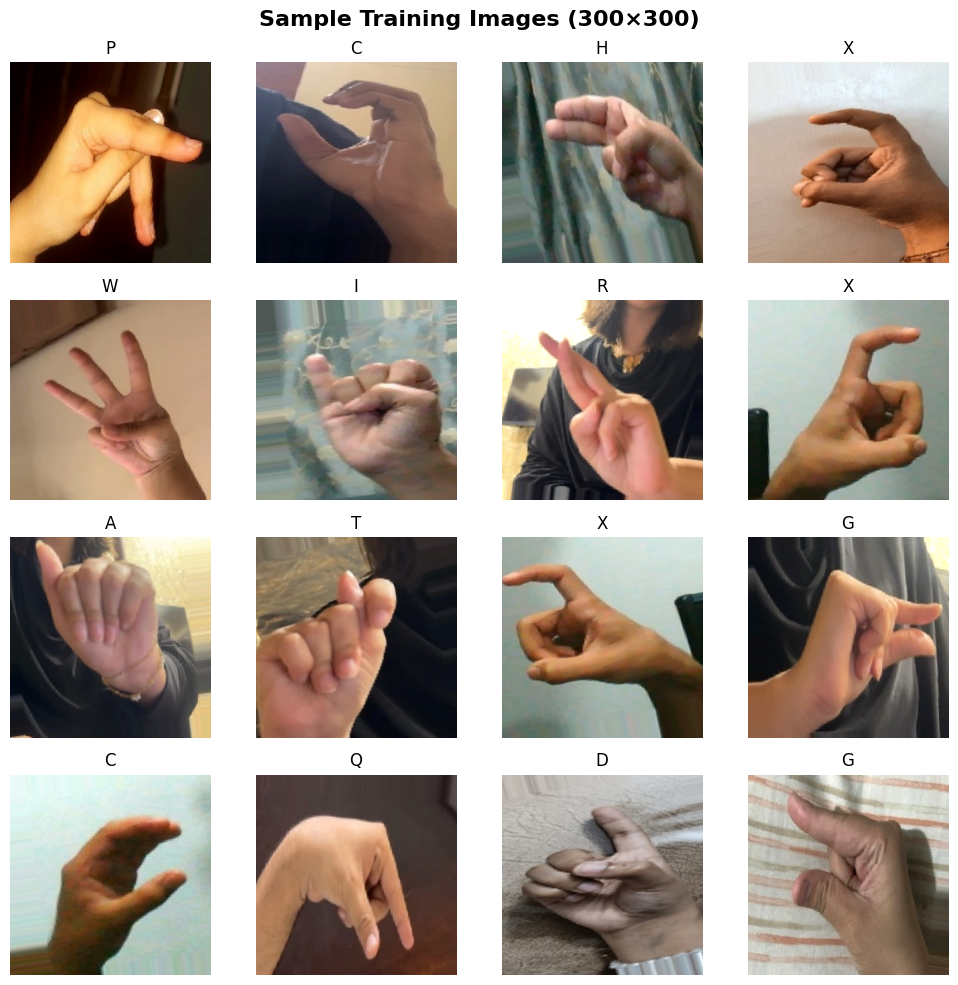

In [ ]:
def show_samples(generator, class_names, n=16):
    imgs, labels = next(generator)

    # Properly normalize each image to [0, 1] for display
    imgs_display = imgs.copy()
    for i in range(len(imgs_display)):
        img = imgs_display[i]
        img = img - img.min()           # shift to 0
        if img.max() > 0:
            img = img / img.max()       # scale to [0, 1]
        imgs_display[i] = img

    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        if i >= n: break
        ax.imshow(imgs_display[i])
        ax.set_title(class_names[np.argmax(labels[i])], fontsize=12)
        ax.axis('off')
    plt.suptitle("Sample Training Images (300×300)", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_samples(train_gen, CLASS_NAMES)

In [ ]:
# --- HYPERPARAMETER UPDATES ---
# Phase 2 LR: 1e-5 -> 2e-5 (Slightly higher to push out of local minima)
# Dropout 1: 0.4 -> 0.45 (Increased to handle unfrozen weights)
# Dropout 2: 0.3 -> 0.35
# Fine-tune From: 300 -> 280 (Unfreezing ~20 additional layers/Block 7)
# Add gradient clipping (VERY useful for EfficientNet fine-tune)

def build_efficientnet_model(input_shape=(300, 300, 3), num_classes=26):
    base_model = keras.applications.EfficientNetB3(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False 
    
    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    
    # Head
    x = layers.GlobalAveragePooling2D()(x)
    
    # Layer 1
    x = layers.Dense(512, use_bias=False,
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Dropout(0.45)(x) # WAS: 0.4 | AFTER: 0.45 (Higher regularization)
    
    # Layer 2
    x = layers.Dense(256, use_bias=False,
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Dropout(0.35)(x) # WAS: 0.3 | AFTER: 0.35
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs, outputs, name="HandSign_EfficientNetB3")
    return model, base_model

model, base_model = build_efficientnet_model(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=NUM_CLASSES
)
model.summary()
print(f"\nTotal backbone layers : {len(base_model.layers)}")
print(f"Trainable backbone layers: {sum(1 for l in base_model.layers if l.trainable)}")


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "HandSign_EfficientNetB3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 26)             │         6,682 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,710,793 (44.67 MB)

 Trainable params: 925,722 (3.53 MB)

 Non-trainable params: 10,785,071 (41.14 MB)


Total backbone layers : 385
Trainable backbone layers: 0


In [ ]:
optimizer = keras.optimizers.AdamW(
    learning_rate=LR_PHASE1,
    weight_decay=1e-4
)

model.compile(
    optimizer=optimizer,
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy',
             keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)


In [ ]:
MODEL_PATH = os.path.join(MODEL_BASE_PATH, "best_handsign_efficientnet.keras")
CHECKPOINT_DIR = os.path.join(MODEL_BASE_PATH, "checkpoints")
HISTORY_PATH = os.path.join(MODEL_BASE_PATH, "training_history.json")
EPOCH_CKPT_PATH = os.path.join(CHECKPOINT_DIR, "handsign_epoch_{epoch:03d}_valacc_{val_accuracy:.4f}.keras")

callbacks_phase1 = [
    ModelCheckpoint(
        MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    ModelCheckpoint(
        EPOCH_CKPT_PATH,
        monitor='val_accuracy',
        save_best_only=False,
        save_weights_only=False,
        verbose=0
    ),
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=6, min_lr=1e-7, verbose=1),
    TensorBoard(log_dir='/content/logs_efficientnet_p1', histogram_freq=1)
]

callbacks_phase2 = [
    ModelCheckpoint(
        MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    ModelCheckpoint(
        EPOCH_CKPT_PATH,
        monitor='val_accuracy',
        save_best_only=False,
        save_weights_only=False,
        verbose=0
    ),
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, min_lr=1e-7, verbose=1),
    TensorBoard(log_dir='/content/logs_efficientnet_p2', histogram_freq=1)
]

# ========================== HELPERS ==========================
def save_history(history_obj, path, phase_key="phase1"):
    data = {}
    if os.path.exists(path):
        with open(path, "r") as f:
            data = json.load(f)

    data[phase_key] = {
        k: [float(x) for x in v] for k, v in history_obj.history.items()
    }

    with open(path, "w") as f:
        json.dump(data, f, indent=2)
    print(f"✅ History saved → {path} [{phase_key}]")


def load_history(path):
    if not os.path.exists(path):
        return {}
    with open(path, "r") as f:
        return json.load(f)


def find_latest_checkpoint(ckpt_dir):
    """Find the most recent checkpoint (ignores best_ models)"""
    pattern = os.path.join(ckpt_dir, "*.keras")
    checkpoints = sorted(glob.glob(pattern))
    # Filter out the "best" model if you have a separate best_handsign...
    checkpoints = [c for c in checkpoints if "best_handsign" not in os.path.basename(c)]

    if not checkpoints:
        return None, 0

    latest = checkpoints[-1]
    basename = os.path.basename(latest)

    try:
        # Extract epoch number from filename
        parts = basename.split("_")
        for p in parts:
            if p.isdigit() and len(p) == 3:  # e.g., 005
                epoch_num = int(p)
                break
        else:
            epoch_num = 0
    except Exception:
        epoch_num = 0

    print(f"🔍 Latest checkpoint found: {latest}")
    print(f"   Resuming from epoch: {epoch_num}")
    return latest, epoch_num


def cleanup_old_checkpoints(ckpt_dir, keep=3):
    pattern = os.path.join(ckpt_dir, "*.keras")
    checkpoints = sorted(glob.glob(pattern))
    checkpoints = [c for c in checkpoints if "best_handsign" not in os.path.basename(c)]

    to_delete = checkpoints[:-keep]
    for ckpt in to_delete:
        try:
            os.remove(ckpt)
            print(f"🗑️ Deleted old checkpoint: {os.path.basename(ckpt)}")
        except Exception as e:
            print(f"⚠️ Could not delete {ckpt}: {e}")


print("✅ Paths, callbacks & helpers ready")
print(f" MODEL_PATH     : {MODEL_PATH}")
print(f" CHECKPOINT_DIR : {CHECKPOINT_DIR}")
print(f" HISTORY_PATH   : {HISTORY_PATH}")

✅ Paths, callbacks & helpers ready
   MODEL_PATH     : /content/drive/MyDrive/ML-CEP/model_efficientnet_final/best_handsign_efficientnet.keras
   CHECKPOINT_DIR : /content/drive/MyDrive/ML-CEP/model_efficientnet_final/checkpoints
   HISTORY_PATH   : /content/drive/MyDrive/ML-CEP/model_efficientnet_final/training_history.json


In [ ]:
EFFICIENTNET_LAYER_NAME = "efficientnetb3"

# Try to resume from latest checkpoint
latest_ckpt, initial_epoch = find_latest_checkpoint(CHECKPOINT_DIR)

if latest_ckpt:
    print(f"\n♻️ RESUMING from checkpoint: {latest_ckpt}")
    model = keras.models.load_model(latest_ckpt)
    base_model = model.get_layer(EFFICIENTNET_LAYER_NAME)
    print("✅ Model loaded successfully!")
else:
    print("\n🆕 No checkpoint found — Starting fresh")

    initial_epoch = 0


PHASE1_TOTAL_EPOCHS = 30


if initial_epoch < PHASE1_TOTAL_EPOCHS:
    print("\n" + "="*60)
    print("🚀 PHASE 1: Training classification head (backbone FROZEN)")
    print(f"   LR     : {LR_PHASE1}")
    print(f"   Epochs : {initial_epoch + 1} → {PHASE1_TOTAL_EPOCHS}")
    print("="*60)

    base_model.trainable = False

    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=LR_PHASE1, weight_decay=1e-4),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
    )

    history1 = model.fit(
        train_gen,
        epochs=PHASE1_TOTAL_EPOCHS,
        initial_epoch=initial_epoch,
        validation_data=val_gen,
        callbacks=callbacks_phase1,
        verbose=1
    )

    save_history(history1, HISTORY_PATH, phase_key="phase1")
    cleanup_old_checkpoints(CHECKPOINT_DIR, keep=3)
    print("✅ Phase 1 completed!")
else:
    print(f"✅ Phase 1 already completed (up to epoch {initial_epoch}). Skipping.")
    history1 = None

🔍 Found checkpoint : /content/drive/MyDrive/ML-CEP/model_efficientnet_final/checkpoints/epoch_020_valacc0.9403.keras
   Resuming from epoch 20

♻️  RESUMING training from: /content/drive/MyDrive/ML-CEP/model_efficientnet_final/checkpoints/epoch_020_valacc0.9403.keras
   Starting at epoch: 21
✅ Model weights loaded successfully!
🔍 Found checkpoint : /content/drive/MyDrive/ML-CEP/model_efficientnet_final/checkpoints/epoch_020_valacc0.9403.keras
   Resuming from epoch 20
♻️  Resuming from : /content/drive/MyDrive/ML-CEP/model_efficientnet_final/checkpoints/epoch_020_valacc0.9403.keras
   Starting epoch : 21

🚀 PHASE 1: Head training — backbone FROZEN
   LR     : 0.001
   Epochs : 21 → 30
Epoch 21/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9082 - loss: 1.1620 - top3_acc: 0.9888
Epoch 21: val_accuracy improved from None to 0.95166, saving model to /content/drive/MyDrive/ML-CEP/model_efficientnet_final/best_handsign_efficientnet.keras

Epoch 21: finished saving model to /conten

In [ ]:
PHASE2_TOTAL_EPOCHS = 50
FINE_TUNE_FROM = 280  # Adjust based on your VRAM (280 ≈ last ~65 layers for EfficientNetB3)

# Reload best Phase 1 model if needed
if os.path.exists(MODEL_PATH) and not latest_ckpt:
    print("📦 Loading best model from Phase 1 to start Phase 2")
    model = keras.models.load_model(MODEL_PATH)
    base_model = model.get_layer(EFFICIENTNET_LAYER_NAME)
    initial_epoch = PHASE1_TOTAL_EPOCHS

if initial_epoch < PHASE2_TOTAL_EPOCHS:
    phase2_start = max(initial_epoch, PHASE1_TOTAL_EPOCHS)

    print("\n" + "="*60)
    print("🔬 PHASE 2: Fine-tuning top layers of EfficientNetB3")
    print(f"   LR                : {LR_PHASE2}")
    print(f"   Unfreezing from   : layer {FINE_TUNE_FROM}+")
    print(f"   Epochs            : {phase2_start + 1} → {PHASE2_TOTAL_EPOCHS}")
    print("="*60)

    base_model.trainable = True
    for layer in base_model.layers[:FINE_TUNE_FROM]:
        layer.trainable = False

    trainable_count = sum(1 for layer in base_model.layers if layer.trainable)
    print(f"   Trainable backbone layers: {trainable_count} / {len(base_model.layers)}")

    # Recompile after changing trainable flags
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=LR_PHASE2, weight_decay=1e-4,clipnorm=1.0),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
    )

    history2 = model.fit(
        train_gen,
        epochs=PHASE2_TOTAL_EPOCHS,
        initial_epoch=phase2_start,
        validation_data=val_gen,
        callbacks=callbacks_phase2,
        verbose=1
    )

    save_history(history2, HISTORY_PATH, phase_key="phase2")
    cleanup_old_checkpoints(CHECKPOINT_DIR, keep=3)
    print("✅ Phase 2 completed!")
else:
    print(f"✅ Phase 2 already completed. Skipping.")
    history2 = None

print("\n🎉 Training finished!")
print(f"   Best model  : {MODEL_PATH}")
print(f"   History     : {HISTORY_PATH}")

🔍 Found checkpoint : /content/drive/MyDrive/ML-CEP/model_efficientnet_final/checkpoints/epoch_030_valacc0.9431.keras
   Resuming from epoch 30
♻️  Resuming Phase 2 from checkpoint: /content/drive/MyDrive/ML-CEP/model_efficientnet_final/checkpoints/epoch_030_valacc0.9431.keras

🔬 PHASE 2: Fine-tuning top EfficientNetB3 layers
   LR              : 1e-05
   Unfreezing from : layer 300+
   Total backbone  : 385 layers
   Epochs          : 31 → 50
   Trainable backbone layers: 85 / 385
Epoch 31/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6831 - loss: 1.7309 - top3_acc: 0.8775
Epoch 31: val_accuracy improved from None to 0.89668, saving model to /content/drive/MyDrive/ML-CEP/model_efficientnet_final/best_handsign_efficientnet.keras

Epoch 31: finished saving model to /content/drive/MyDrive/ML-CEP/model_efficientnet_final/best_handsign_efficientnet.keras
117/117 ━━━━━━━━━━━━━━━━━━━━ 220s 1s/step - accuracy: 0.7064 - loss: 1.6591 - top3_acc: 0.8982 - val_accuracy: 0.8967 - val_los

In [ ]:
def plot_history(h1, h2=None):
    # Load from saved JSON if histories are None (crash recovery)
    if h1 is None or h2 is None:
        saved = load_history(HISTORY_PATH)
        phase1_data = saved.get("phase1", {})
        phase2_data = saved.get("phase2", {})

        acc   = phase1_data.get('accuracy', [])
        vacc  = phase1_data.get('val_accuracy', [])
        loss  = phase1_data.get('loss', [])
        vloss = phase1_data.get('val_loss', [])

        phase_split = len(acc)

        if phase2_data:
            acc   += phase2_data.get('accuracy', [])
            vacc  += phase2_data.get('val_accuracy', [])
            loss  += phase2_data.get('loss', [])
            vloss += phase2_data.get('val_loss', [])
    else:
        acc   = h1.history.get('accuracy', []) if h1 else []
        vacc  = h1.history.get('val_accuracy', []) if h1 else []
        loss  = h1.history.get('loss', []) if h1 else []
        vloss = h1.history.get('val_loss', []) if h1 else []

        phase_split = len(acc)

        if h2:
            acc   += h2.history.get('accuracy', [])
            vacc  += h2.history.get('val_accuracy', [])
            loss  += h2.history.get('loss', [])
            vloss += h2.history.get('val_loss', [])

    if not acc:
        print("⚠️ No history data available for plotting.")
        return

    epochs_range = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    ax1.plot(epochs_range, acc,  label='Train Acc',  color='royalblue')
    ax1.plot(epochs_range, vacc, label='Val Acc',    color='tomato')
    if h2 or phase2_data:
        ax1.axvline(phase_split, color='gray', linestyle='--', label='Phase 2 start')
    ax1.set_title('Accuracy', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs_range, loss,  label='Train Loss', color='royalblue')
    ax2.plot(epochs_range, vloss, label='Val Loss',   color='tomato')
    if h2 or phase2_data:
        ax2.axvline(phase_split, color='gray', linestyle='--', label='Phase 2 start')
    ax2.set_title('Loss', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle('EfficientNetB3 Handsign Training History', fontsize=16, fontweight='bold')
    plt.tight_layout()

    plot_path = os.path.join(MODEL_BASE_PATH, 'training_history.png')
    plt.savefig(plot_path, dpi=200, bbox_inches='tight')
    print(f"📊 Plot saved to: {plot_path}")
    plt.show()


# Call the plot (works even after crash)
plot_history(history1, history2)

In [ ]:
print("\n" + "="*55)
print("🧪 TEST SET EVALUATION")
print("="*55)

best_model = keras.models.load_model(MODEL_PATH)

test_loss, test_acc, test_top3 = best_model.evaluate(test_gen, verbose=1)
print(f"\n✅ Test Accuracy  : {test_acc * 100:.2f}%")
print(f"✅ Top-3 Accuracy : {test_top3 * 100:.2f}%")
print(f"✅ Test Loss      : {test_loss:.4f}")



🧪 TEST SET EVALUATION
18/18 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.9745 - loss: 1.0165 - top3_acc: 1.0000

✅ Test Accuracy  : 97.45%
✅ Top-3 Accuracy : 100.00%
✅ Test Loss      : 1.0165


18/18 ━━━━━━━━━━━━━━━━━━━━ 28s 901ms/step

📋 Classification Report:
              precision    recall  f1-score   support

           A       0.91      0.95      0.93        22
           B       1.00      1.00      1.00        20
           C       1.00      1.00      1.00        19
           D       1.00      1.00      1.00        22
           E       1.00      1.00      1.00        23
           F       0.95      1.00      0.98        21
           G       1.00      1.00      1.00        22
           H       0.91      1.00      0.95        20
           I       1.00      1.00      1.00        22
           J       0.87      0.91      0.89        22
           K       1.00      1.00      1.00        21
           L       1.00      0.95      0.98        21
           M       0.95      1.00      0.98        21
           N       1.00      0.95      0.97        20
           O       1.00      1.00      1.00        20
           P       1.00      1.00      1.00        22
           Q 

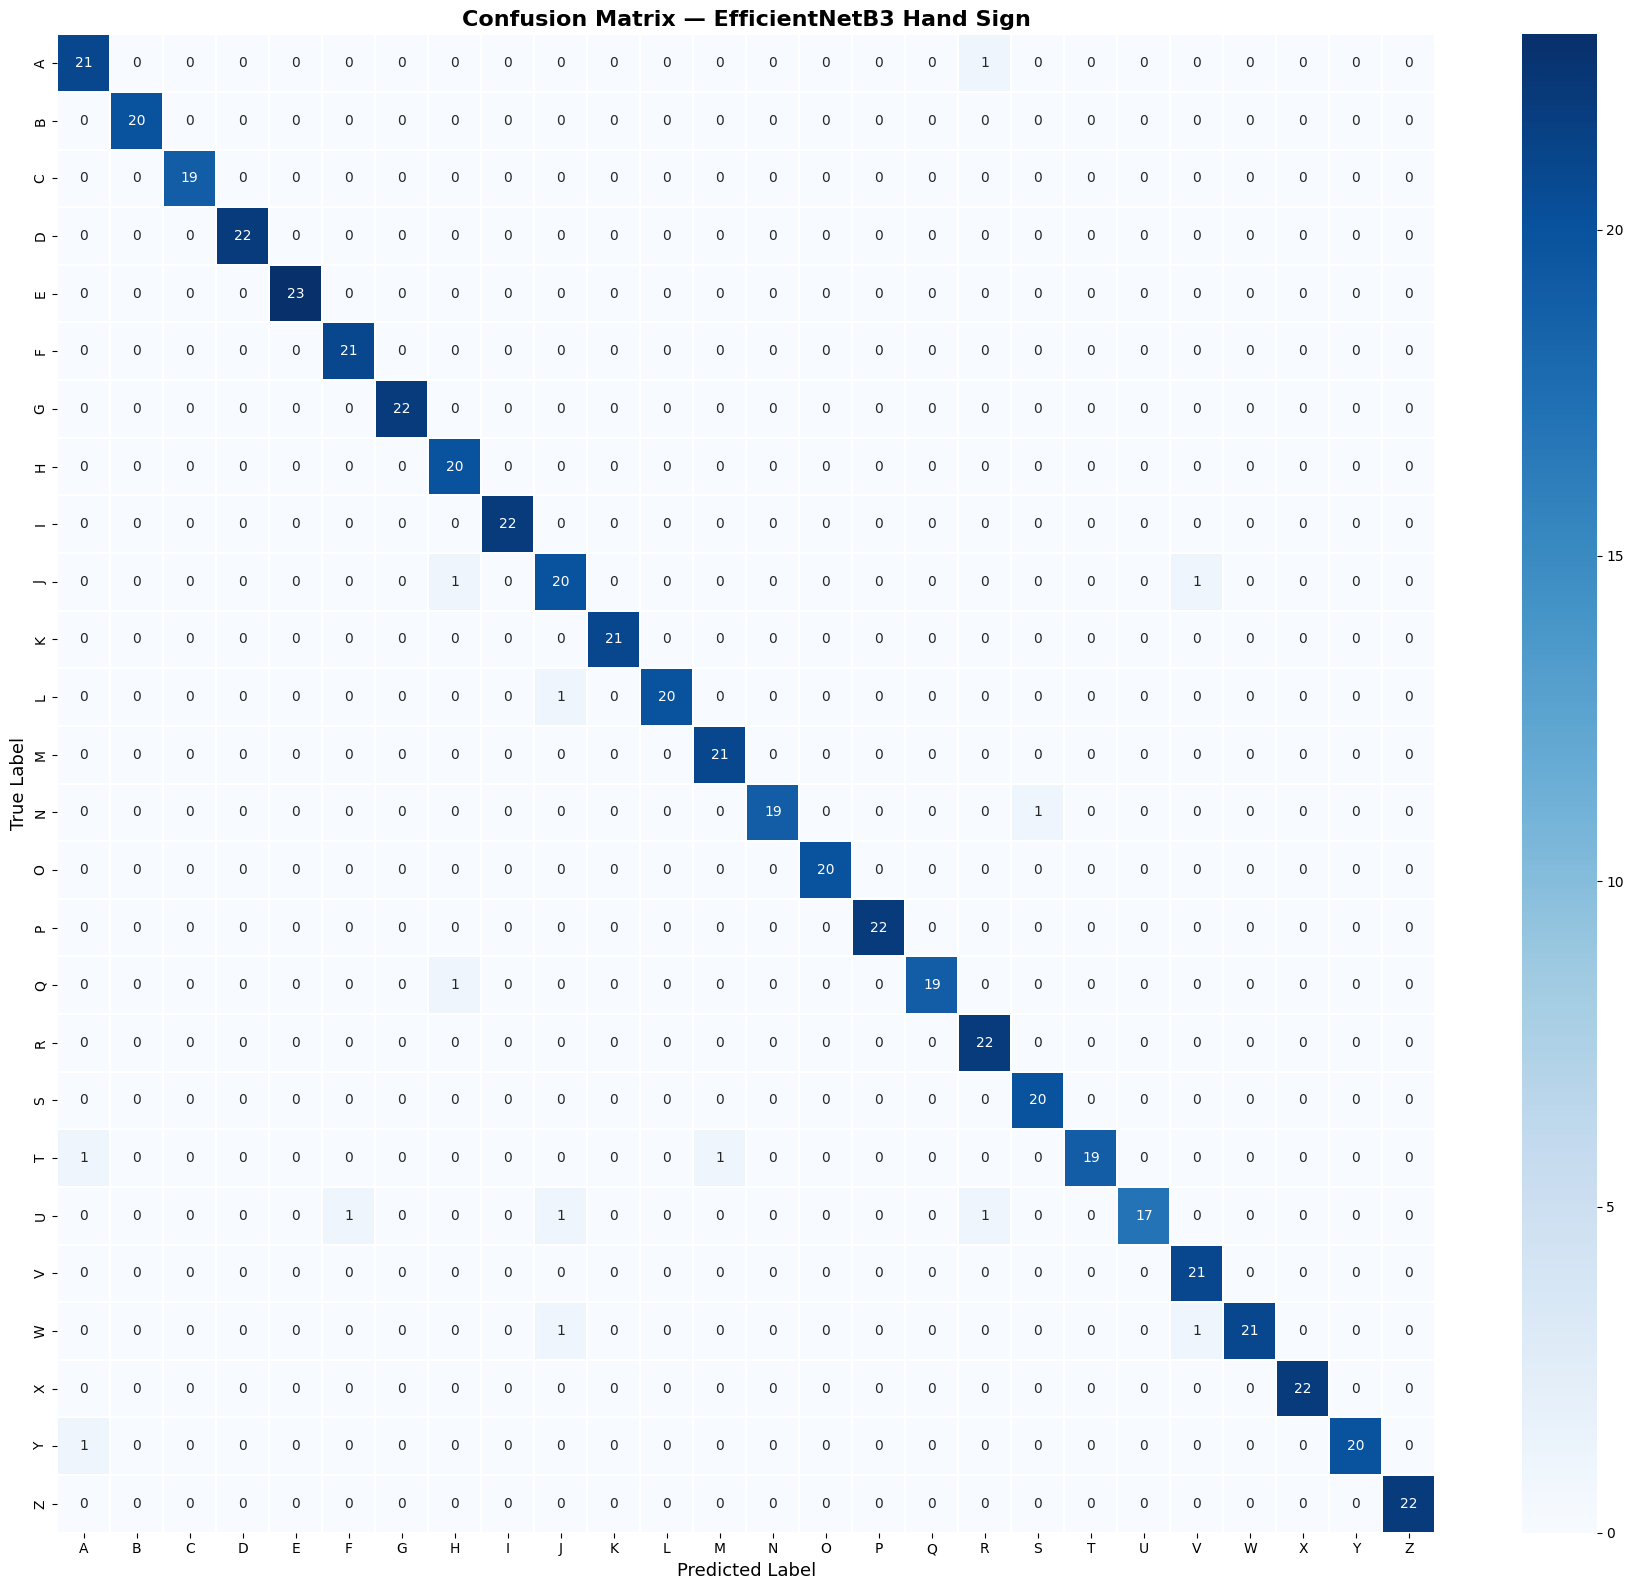

In [ ]:
test_gen.reset()
y_pred_probs = best_model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(18, 16))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            linewidths=0.3)
plt.title('Confusion Matrix — EfficientNetB3 Hand Sign', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=13)
plt.xlabel('Predicted Label', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_BASE_PATH, 'confusion_matrix.png'), dpi=150)
plt.show()


In [ ]:
print("\n📊 Per-Class Accuracy:")
print("-" * 30)
for i, cls in enumerate(CLASS_NAMES):
    mask = (y_true == i)
    if mask.sum() == 0:
        continue
    cls_acc = (y_pred[mask] == y_true[mask]).mean() * 100
    bar = "█" * int(cls_acc / 5)
    print(f"  {cls}: {cls_acc:6.2f}%  {bar}")


📊 Per-Class Accuracy:
------------------------------
  A:  95.45%  ███████████████████
  B: 100.00%  ████████████████████
  C: 100.00%  ████████████████████
  D: 100.00%  ████████████████████
  E: 100.00%  ████████████████████
  F: 100.00%  ████████████████████
  G: 100.00%  ████████████████████
  H: 100.00%  ████████████████████
  I: 100.00%  ████████████████████
  J:  90.91%  ██████████████████
  K: 100.00%  ████████████████████
  L:  95.24%  ███████████████████
  M: 100.00%  ████████████████████
  N:  95.00%  ███████████████████
  O: 100.00%  ████████████████████
  P: 100.00%  ████████████████████
  Q:  95.00%  ███████████████████
  R: 100.00%  ████████████████████
  S: 100.00%  ████████████████████
  T:  90.48%  ██████████████████
  U:  85.00%  █████████████████
  V: 100.00%  ████████████████████
  W:  91.30%  ██████████████████
  X: 100.00%  ████████████████████
  Y:  95.24%  ███████████████████
  Z: 100.00%  ████████████████████


In [ ]:
# 1. Best Keras model already saved by ModelCheckpoint
print(f"\n✅ Best model saved: {MODEL_PATH}")

# 2. Save label / class index map
label_map_path = os.path.join(MODEL_BASE_PATH, "class_indices.json")
with open(label_map_path, "w") as f:
    json.dump(train_gen.class_indices, f)
print(f"✅ Class indices saved: {label_map_path}")

# 3. TFLite (quantized) for mobile/edge deployment
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
tflite_path    = os.path.join(MODEL_BASE_PATH, "handsign_efficientnet.tflite")
with open(tflite_path, "wb") as f:
    f.write(tflite_model)
print(f"✅ TFLite model saved: {tflite_path}")



✅ Best model saved: /content/drive/MyDrive/ML-CEP/model_efficientnet_final/best_handsign_efficientnet.keras
✅ Class indices saved: /content/drive/MyDrive/ML-CEP/model_efficientnet_final/class_indices.json
Saved artifact at '/tmp/tmp7i8i7b5g'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 26), dtype=tf.float32, name=None)
Captures:
  136545116389648: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  136545116390224: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  136544494382224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136544494379920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136544494380688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136544494382800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136544494386064: TensorSpec(shape=(), dtype=tf.resource, name=None)
